# Практическая работа № 5

**Цель работы:** познакомиться с архитектурой автоэнкодеров и изучить, как нейронная сеть может использоваться для восстановления входных данных и выявления аномальных объектов. Освоить построение и обучение автоэнкодера для задачи обнаружения аномалий на табличных данных или временных рядах.

**Задачи:**

1. Построить и обучить модель:
* Разделить данные на обучающую и тестовую выборки.
* Построить автоэнкодер.
* Обучить модель восстанавливать входные данные.
* Построить график функции потерь на обучающей и валидационной выборках.
* Выбрать функцию потерь и объяснить, почему она подходит для данной задачи.
* Рассчитать ошибку восстановления для объектов тестовой выборки.
* Выбрать порог, по которому объект считается аномальным.
* Рассчитать метрики качества.

2. Для выбранной модели рассмотреть разные варианты обучения: поменять гиперпараметры, количество слоев, функции активации, оптимизаторы.
3. Сравнить результаты и сделать выводы.

---

**Теоретическая справка**

Автоэнкодер — это архитектура нейронной сети, предназначенная для обучения компактного представления данных и восстановления входной информации. Модель получает на вход объект, сжимает его до скрытого представления меньшей размерности, а затем пытается восстановить исходные данные. Автоэнкодеры применяются для различных задач: снижения размерности, восстановления поврежденных данных, генерации признаков. В данной работе рассматривается задача обнаружения аномальных объектов.

**Архитектура автоэнкодера**

Автоэнкодер состоит из двух основных частей:
* Encoder (кодировщик) — преобразует входные данные в скрытое представление меньшей размерности
* Decoder (декодировщик) — восстанавливает исходные данные из скрытого представления

Между encoder и decoder находится bottleneck-представление — наиболее сжатое описание объекта. В этом слое сеть учится выделять наиболее важные признаки данных.

В работе используется полносвязный автоэнкодер (Dense Autoencoder), построенный на линейных слоях. Для введения нелинейности используются функции активации ReLU. На выходном слое используется линейная активация, так как задача связана с восстановлением числовых признаков.

**Задача**

В данной работе решается задача обнаружения аномалий в банковских транзакциях: необходимо определить, является операция нормальной или мошеннической. Для этого используется автоэнкодер, обучаемый восстанавливать нормальные транзакции. После обучения рассчитывается ошибка восстановления объектов тестовой выборки, на основе которой определяется наличие аномалии.

Автоэнкодер обучается восстанавливать нормальные объекты: во время обучения сеть запоминает закономерности, характерные для обычных данных, и учится хорошо их реконструировать. Если на вход подается объект, сильно отличающийся от нормальных данных, автоэнкодер восстанавливает его значительно хуже и ошибка становится большой. Для определения аномалий выбирается некоторый порог этой ошибки восстановления и если ошибка объекта превышает порог, он считается аномальным.

**Выбранная архитектура**

В работе используется симметричный полносвязный автоэнкодер. Encoder постепенно уменьшает размерность признакового пространства, формируя компактное скрытое представление данных, а Decoder выполняет обратное преобразование и восстанавливает исходные признаки. В качестве функции потерь используется MSELoss (среднеквадратичная ошибка), так как задача заключается в восстановлении числовых признаков и сравнении восстановленных значений с исходными. Для оптимизации используется алгоритм Adam, обеспечивающий стабильное и быстрое обучение нейронной сети.


In [ ]:
# Используемые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix

## 1. Загрузка датасета

Для выполнения работы используется датасет Credit Card Fraud Detection, содержащий информацию о банковских транзакциях:
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Датасет включает числовые признаки транзакций и метку класса:
* 0 — нормальная транзакция
* 1 — мошенническая транзакция

Большинство признаков было преобразовано методом PCA и представлены в виде анонимизированных компонент V1–V28. Дополнительно присутствуют признаки Time и Amount.

Датасет является несбалансированным, поскольку мошеннические операции встречаются значительно реже обычных. Для обучения автоэнкодера будут использоваться преимущественно нормальные объекты, чтобы модель изучила структуру корректных транзакций.

In [ ]:
# Загрузка данных
df = pd.read_csv('creditcard.csv')

print(f"Размер датасета: {df.shape}")
display(df.head())
print(df.info())

Размер датасета: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Проверим дисбаланс.

/tmp/ipykernel_9830/4081542969.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['Class'], sort = True)


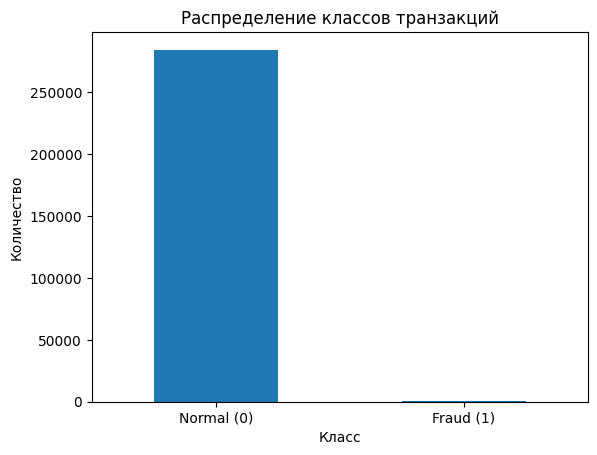

Нормальные транзакции: 284315
Мошеннические транзакции: 492


In [ ]:
count_classes = pd.value_counts(df['Class'], sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("Распределение классов транзакций")
plt.xticks(range(2), ['Normal (0)', 'Fraud (1)'])
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.show()

print(f"Нормальные транзакции: {count_classes[0]}")
print(f"Мошеннические транзакции: {count_classes[1]}")

График наглядно показывает, почему мы используем автоэнкодер. Огромный дисбаланс (мошеннических операций совсем мало) делает классическую классификацию сложной, поэтому мы учим модель только на классе 0.

Масштабируем Amount, чтобы привести его к диапазону, схожему с остальными признаками (V1-V28, которые уже после PCA). Это необходимо для корректной работы функции потерь MSE. Затем разделяем данные на нормальные и аномальные.

In [ ]:
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))

# Удаляем колонки Time (не нужна для задачи) и старый Amount
df = df.drop(['Time', 'Amount'], axis=1)

normal_data = df[df['Class'] == 0].drop(['Class'], axis=1)
fraud_data = df[df['Class'] == 1].drop(['Class'], axis=1)

print(f"Количество нормальных записей: {len(normal_data)}")
print(f"Количество аномальных записей: {len(fraud_data)}")

Количество нормальных записей: 284315
Количество аномальных записей: 492


Разделим нормальные транзакции на обучающую и валидационную выборки. Обучение автоэнкодера будет происходить только на нормальных данных, чтобы модель изучила структуру именно корректных операций. Аномалии оставим только для тестирования.


После разделения данных преобразуем их в тензоры PyTorch и создадим DataLoader для пакетной загрузки данных во время обучения.

In [ ]:
train_data, val_normal = train_test_split(
    normal_data,
    test_size=0.2,
    random_state=42
)

# validation только из нормальных данных
X_val = torch.FloatTensor(val_normal.values)

# тест = нормальные + аномальные
test_data = pd.concat([val_normal, fraud_data])

y_test = np.array([0] * len(val_normal) + [1] * len(fraud_data))

X_train = torch.FloatTensor(train_data.values)
X_test = torch.FloatTensor(test_data.values)
y_test = torch.tensor(y_test)

train_loader = DataLoader(
    TensorDataset(X_train, X_train),
    batch_size=32,
    shuffle=True
)

## 2. Построение и обучение модели

Построим полносвязный автоэнкодер. Используем MSELoss, она хорошо подходит, так как мы сравниваем числа (признаки) на входе и выходе. Если модель ошибается в восстановлении признака, MSE штрафует её пропорционально квадрату ошибки.

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        # Encoder сжимает данные
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 14),
            nn.ReLU(),
            nn.Linear(14, 7),
            nn.ReLU()
        )
        # Decoder восстанавливает данные
        self.decoder = nn.Sequential(
            nn.Linear(7, 14),
            nn.ReLU(),
            nn.Linear(14, input_dim)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = Autoencoder(input_dim=X_train.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Обучим модель на 20 эпохах.

In [ ]:
epochs = 20
train_losses = []
val_losses = []

for epoch in range(epochs):
    # Обучение
    model.train()
    train_epoch_loss = 0

    for data in train_loader:
        inputs, _ = data
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        train_epoch_loss += loss.item()

    avg_train_loss = train_epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, X_val)

    val_losses.append(val_loss.item())

    print(f"Epoch {epoch+1}: "
        f"Train Loss = {avg_train_loss:.4f}, "
        f"Val Loss = {val_loss.item():.4f}")

Epoch 1: Train Loss = 0.5078, Val Loss = 0.4307
Epoch 2: Train Loss = 0.4114, Val Loss = 0.4015
Epoch 3: Train Loss = 0.3934, Val Loss = 0.3926
Epoch 4: Train Loss = 0.3863, Val Loss = 0.3845
Epoch 5: Train Loss = 0.3811, Val Loss = 0.3786
Epoch 6: Train Loss = 0.3765, Val Loss = 0.3776
Epoch 7: Train Loss = 0.3735, Val Loss = 0.3745
Epoch 8: Train Loss = 0.3726, Val Loss = 0.3743
Epoch 9: Train Loss = 0.3722, Val Loss = 0.3741
Epoch 10: Train Loss = 0.3718, Val Loss = 0.3753
Epoch 11: Train Loss = 0.3714, Val Loss = 0.3723
Epoch 12: Train Loss = 0.3710, Val Loss = 0.3738
Epoch 13: Train Loss = 0.3709, Val Loss = 0.3730
Epoch 14: Train Loss = 0.3711, Val Loss = 0.3726
Epoch 15: Train Loss = 0.3707, Val Loss = 0.3724
Epoch 16: Train Loss = 0.3707, Val Loss = 0.3699
Epoch 17: Train Loss = 0.3699, Val Loss = 0.3732
Epoch 18: Train Loss = 0.3704, Val Loss = 0.3717
Epoch 19: Train Loss = 0.3704, Val Loss = 0.3714
Epoch 20: Train Loss = 0.3705, Val Loss = 0.3698


Посмотрим графики функций потерь на тренировочной и валидационной выборке.

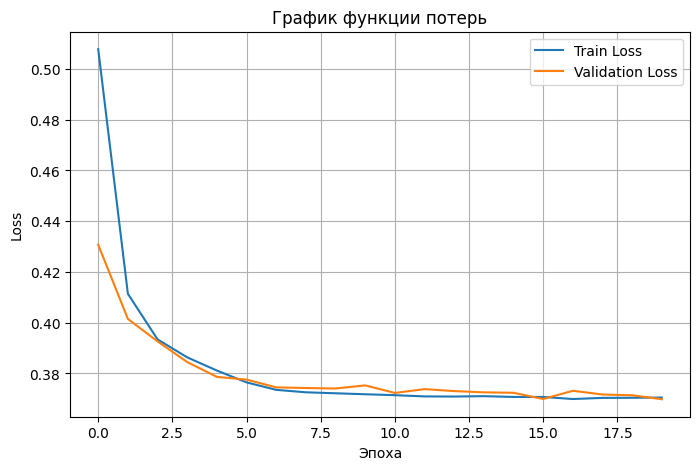

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("График функции потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

По графику функции потерь можно увидеть, что ошибка восстановления постепенно уменьшается как на обучающей, так и на валидационной выборке, автоэнкодер успешно обучается восстанавливать нормальные транзакции. Признаков переобучения нет.


Рассчитаем ошибку восстановления для каждого объекта тестовой выборки. Для этого вычисляется среднеквадратичная ошибка между исходными и восстановленными признаками, чем она выше, тем больше вероятность, что объект является аномалией.

Для определения аномалий выберем порог ошибки, например, 95-й перцентиль ошибки на нормальных объектах, то есть 95% нормальных транзакций имеют ошибку ниже выбранного значения.



In [ ]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    # MSE для каждого объекта
    mse = torch.mean((predictions - X_test)**2, axis=1).numpy()

# Выбираем порог
threshold = np.quantile(mse[y_test == 0], 0.95)
print(f"Порог аномальности: {threshold:.4f}")

# Классификация
preds = (mse > threshold).astype(int)

Порог аномальности: 0.7996


Так как у нас сильный дисбаланс, Accuracy не поможет для оценки качества. Используем Confusion Matrix и Classification Report.

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56863
           1       0.12      0.83      0.22       492

    accuracy                           0.95     57355
   macro avg       0.56      0.89      0.60     57355
weighted avg       0.99      0.95      0.97     57355



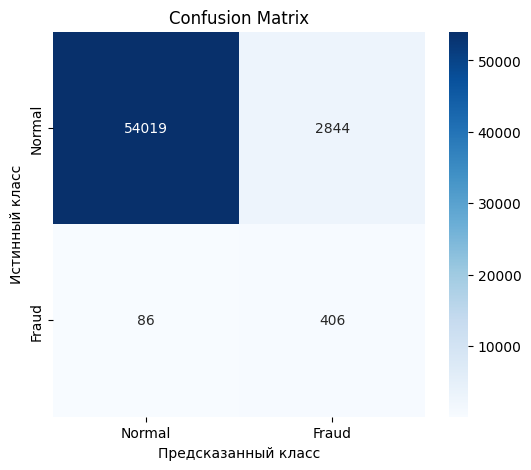

In [ ]:
print(classification_report(y_test, preds))
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)

plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Confusion Matrix")
plt.show()

Результаты классификации показывают, что модель успешно справляется с определением нормальных транзакций (Recall 0.95), однако при обнаружении мошеннических операций наблюдается высокая доля ложноположительных срабатываний, что отражается в низком Precision (0.12). Матрица ошибок подтверждает, что из 492 мошеннических транзакций модель верно определила 406 (Recall 0.83), но при этом 2844 нормальных транзакции были ошибочно классифицированы как мошеннические. Установленный порог 0.7996 позволяет эффективно выявлять большинство аномалий, однако вызывает большое количество ложных срабатываний, что характерно для автоэнкодеров при работе с сильно несбалансированными данными.


## 3. Эксперименты с архитектурой

### Увеличение количества слоев

Базовая модель содержала два скрытых слоя, построим новую архитектуру с тремя скрытыми слоями. Предполагается, что более глубокая сеть сможет лучше выделять сложные закономерности в данных и точнее восстанавливать нормальные транзакции.


In [ ]:
class DeepAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(DeepAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 20),
            nn.ReLU(),
            nn.Linear(20, 14),
            nn.ReLU(),
            nn.Linear(14, 7),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(7, 14),
            nn.ReLU(),
            nn.Linear(14, 20),
            nn.ReLU(),
            nn.Linear(20, input_dim)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

Используем тот же цикл обучения.

Epoch 1: Train Loss = 0.4746, Val Loss = 0.3707
Epoch 2: Train Loss = 0.3362, Val Loss = 0.3138
Epoch 3: Train Loss = 0.3017, Val Loss = 0.2860
Epoch 4: Train Loss = 0.2791, Val Loss = 0.2717
Epoch 5: Train Loss = 0.2719, Val Loss = 0.2645
Epoch 6: Train Loss = 0.2671, Val Loss = 0.2715
Epoch 7: Train Loss = 0.2632, Val Loss = 0.2574
Epoch 8: Train Loss = 0.2556, Val Loss = 0.2419
Epoch 9: Train Loss = 0.2411, Val Loss = 0.2355
Epoch 10: Train Loss = 0.2365, Val Loss = 0.2321
Epoch 11: Train Loss = 0.2339, Val Loss = 0.2294
Epoch 12: Train Loss = 0.2319, Val Loss = 0.2346
Epoch 13: Train Loss = 0.2300, Val Loss = 0.2248
Epoch 14: Train Loss = 0.2280, Val Loss = 0.2392
Epoch 15: Train Loss = 0.2266, Val Loss = 0.2233
Epoch 16: Train Loss = 0.2256, Val Loss = 0.2257
Epoch 17: Train Loss = 0.2253, Val Loss = 0.2194
Epoch 18: Train Loss = 0.2232, Val Loss = 0.2435
Epoch 19: Train Loss = 0.2219, Val Loss = 0.2140
Epoch 20: Train Loss = 0.2193, Val Loss = 0.2144


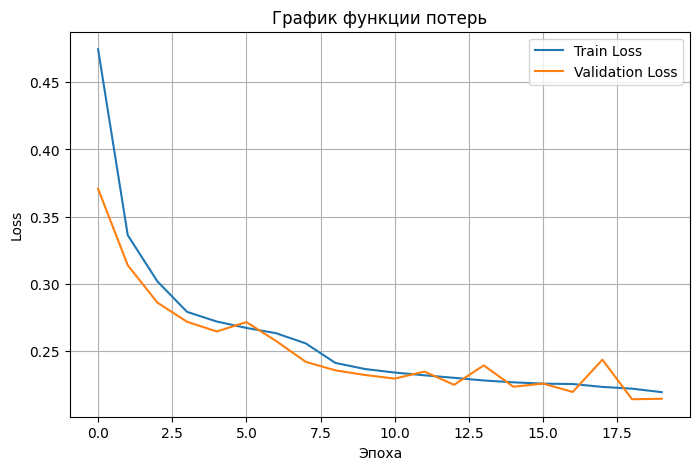

In [ ]:
epochs = 20
train_losses = []
val_losses = []
model = DeepAutoencoder(input_dim=X_train.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(epochs):
    # Обучение
    model.train()
    train_epoch_loss = 0

    for data in train_loader:
        inputs, _ = data
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        train_epoch_loss += loss.item()

    avg_train_loss = train_epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, X_val)

    val_losses.append(val_loss.item())

    print(f"Epoch {epoch+1}: "
        f"Train Loss = {avg_train_loss:.4f}, "
        f"Val Loss = {val_loss.item():.4f}")

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("График функции потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

Порог аномальности: 0.5183
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56863
           1       0.13      0.86      0.22       492

    accuracy                           0.95     57355
   macro avg       0.56      0.90      0.60     57355
weighted avg       0.99      0.95      0.97     57355



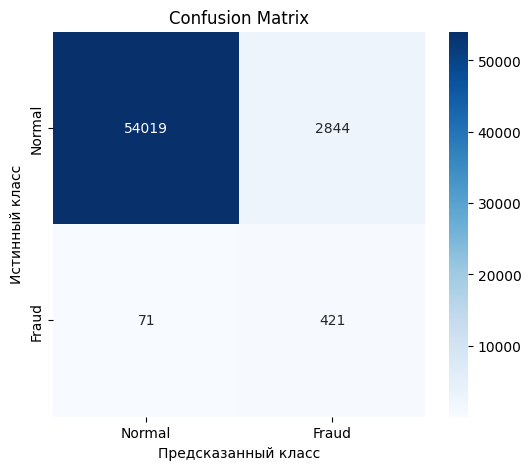

In [ ]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    mse = torch.mean((predictions - X_test)**2, axis=1).numpy()

threshold = np.quantile(mse[y_test == 0], 0.95)
print(f"Порог аномальности: {threshold:.4f}")
preds = (mse > threshold).astype(int)

print(classification_report(y_test, preds))
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)

plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Confusion Matrix")
plt.show()

График функции потерь демонстрирует стабильное снижение ошибки как на обучающей, так и на валидационной выборках, что свидетельствует об успешном процессе обучения без признаков переобучения. Хотя заметны небольшие скачки, сами значения Loss стали ниже. По сравнению с базовой моделью, использование более глубокой архитектуры позволило улучшить способность сети выявлять аномалии: показатель Recall для мошеннических транзакций вырос с 0.83 до 0.86, а количество верно классифицированных аномалий увеличилось с 406 до 421. Улучшение метрик вызвано тем, что дополнительная глубина сети позволила лучше аппроксимировать нелинейные зависимости в данных.

Несмотря на сохраняющуюся низкую точность (Precision), модель стала более чувствительной к выявлению мошеннических операций, что является более приоритетным в данной задаче.

### Изменение функции активации

Вместо функции активации ReLU используем LeakyReLU. Она отличается тем, что пропускает небольшие отрицательные значения, благодаря чему уменьшается вероятность появления мертвых нейронов и обучение может стать более стабильным.


In [ ]:
class LeakyAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(LeakyAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 14),
            nn.LeakyReLU(0.1),
            nn.Linear(14, 7),
            nn.LeakyReLU(0.1)
        )

        self.decoder = nn.Sequential(
            nn.Linear(7, 14),
            nn.LeakyReLU(0.1),
            nn.Linear(14, input_dim)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

Epoch 1: Train Loss = 0.4940, Val Loss = 0.3830
Epoch 2: Train Loss = 0.3570, Val Loss = 0.3310
Epoch 3: Train Loss = 0.3213, Val Loss = 0.3101
Epoch 4: Train Loss = 0.3136, Val Loss = 0.3134
Epoch 5: Train Loss = 0.3104, Val Loss = 0.3053
Epoch 6: Train Loss = 0.3077, Val Loss = 0.3058
Epoch 7: Train Loss = 0.3060, Val Loss = 0.3000
Epoch 8: Train Loss = 0.3042, Val Loss = 0.2991
Epoch 9: Train Loss = 0.3032, Val Loss = 0.2986
Epoch 10: Train Loss = 0.3017, Val Loss = 0.2982
Epoch 11: Train Loss = 0.3007, Val Loss = 0.2972
Epoch 12: Train Loss = 0.2991, Val Loss = 0.2943
Epoch 13: Train Loss = 0.2949, Val Loss = 0.2909
Epoch 14: Train Loss = 0.2900, Val Loss = 0.2853
Epoch 15: Train Loss = 0.2875, Val Loss = 0.2817
Epoch 16: Train Loss = 0.2859, Val Loss = 0.2804
Epoch 17: Train Loss = 0.2848, Val Loss = 0.2884
Epoch 18: Train Loss = 0.2836, Val Loss = 0.2790
Epoch 19: Train Loss = 0.2829, Val Loss = 0.2787
Epoch 20: Train Loss = 0.2823, Val Loss = 0.2772


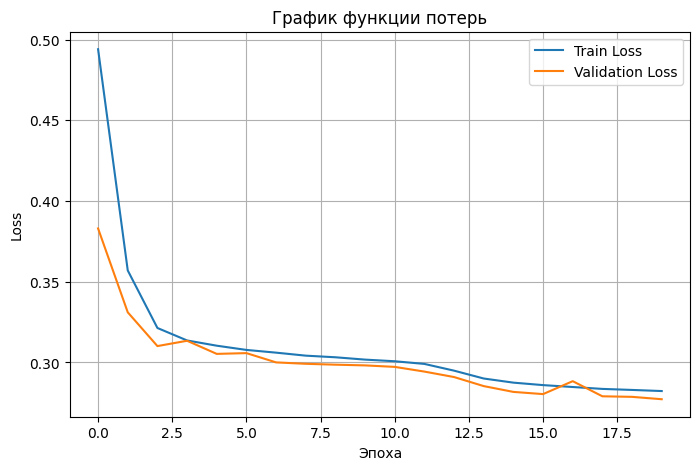

In [ ]:
epochs = 20
train_losses = []
val_losses = []
model = LeakyAutoencoder(input_dim=X_train.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

for epoch in range(epochs):
    # Обучение
    model.train()
    train_epoch_loss = 0

    for data in train_loader:
        inputs, _ = data
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        train_epoch_loss += loss.item()

    avg_train_loss = train_epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, X_val)

    val_losses.append(val_loss.item())

    print(f"Epoch {epoch+1}: "
        f"Train Loss = {avg_train_loss:.4f}, "
        f"Val Loss = {val_loss.item():.4f}")

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("График функции потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

Порог аномальности: 0.6106
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56863
           1       0.13      0.85      0.22       492

    accuracy                           0.95     57355
   macro avg       0.56      0.90      0.60     57355
weighted avg       0.99      0.95      0.97     57355



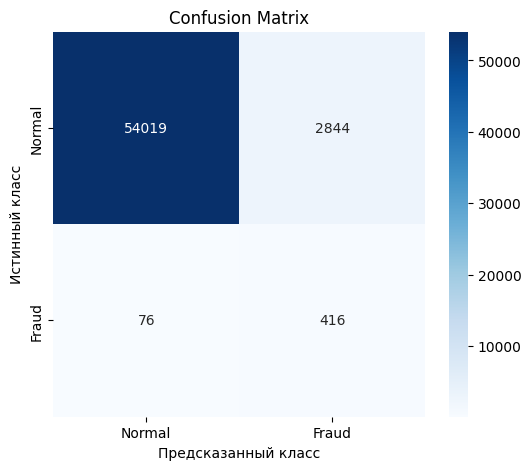

In [ ]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    mse = torch.mean((predictions - X_test)**2, axis=1).numpy()

threshold = np.quantile(mse[y_test == 0], 0.95)
print(f"Порог аномальности: {threshold:.4f}")
preds = (mse > threshold).astype(int)

print(classification_report(y_test, preds))
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)

plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Confusion Matrix")
plt.show()

Динамика обучения стала более стабильной, чем у предыдущей модели. На графике функции потерь кривые Train Loss и Validation Loss демонстрируют плавное и монотонное снижение без сильных скачков. Все ещё менее плавно, чем базовая модель, но значения ошибки значительно ниже. По результатам классификации метрики показали сопоставимую с глубоким автоэнкодером эффективность (Recall 0.85), при этом сохранился баланс между выявлением аномалий и количеством ложных срабатываний.

Данный эксперимент подтверждает, что выбор функции активации является важным гиперпараметром, позволяющим предотвратить затухание градиентов и ускорить сходимость модели.

### Изменение оптимизатора

Вместо Adam используем RMSprop для первой базовой модели. Оптимизатор влияет на скорость и стабильность обновления весов нейронной сети, поэтому выбор алгоритма оптимизации может существенно влиять на качество обучения модели.


In [ ]:
model = Autoencoder(input_dim=X_train.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.RMSprop(
    model.parameters(),
    lr=0.001
)

Epoch 1: Train Loss = 0.4502, Val Loss = 0.4087
Epoch 2: Train Loss = 0.3495, Val Loss = 0.3402
Epoch 3: Train Loss = 0.3270, Val Loss = 0.3241
Epoch 4: Train Loss = 0.3164, Val Loss = 0.3164
Epoch 5: Train Loss = 0.3112, Val Loss = 0.3108
Epoch 6: Train Loss = 0.3043, Val Loss = 0.3341
Epoch 7: Train Loss = 0.3005, Val Loss = 0.3015
Epoch 8: Train Loss = 0.2983, Val Loss = 0.3008
Epoch 9: Train Loss = 0.2968, Val Loss = 0.3056
Epoch 10: Train Loss = 0.2950, Val Loss = 0.2953
Epoch 11: Train Loss = 0.2940, Val Loss = 0.3007
Epoch 12: Train Loss = 0.2930, Val Loss = 0.2934
Epoch 13: Train Loss = 0.2920, Val Loss = 0.2907
Epoch 14: Train Loss = 0.2897, Val Loss = 0.2865
Epoch 15: Train Loss = 0.2862, Val Loss = 0.2823
Epoch 16: Train Loss = 0.2837, Val Loss = 0.2848
Epoch 17: Train Loss = 0.2823, Val Loss = 0.2772
Epoch 18: Train Loss = 0.2810, Val Loss = 0.2769
Epoch 19: Train Loss = 0.2799, Val Loss = 0.2758
Epoch 20: Train Loss = 0.2793, Val Loss = 0.2776


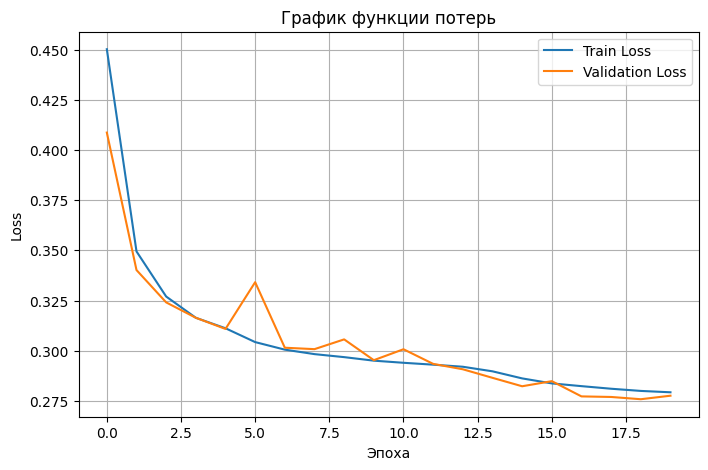

In [ ]:
epochs = 20
train_losses = []
val_losses = []

for epoch in range(epochs):
    # Обучение
    model.train()
    train_epoch_loss = 0

    for data in train_loader:
        inputs, _ = data
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        train_epoch_loss += loss.item()

    avg_train_loss = train_epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, X_val)

    val_losses.append(val_loss.item())

    print(f"Epoch {epoch+1}: "
        f"Train Loss = {avg_train_loss:.4f}, "
        f"Val Loss = {val_loss.item():.4f}")

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("График функции потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

Порог аномальности: 0.6388
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56863
           1       0.13      0.89      0.23       492

    accuracy                           0.95     57355
   macro avg       0.57      0.92      0.60     57355
weighted avg       0.99      0.95      0.97     57355



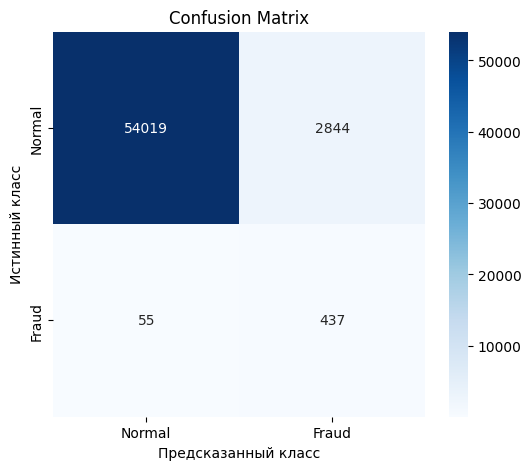

In [ ]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    mse = torch.mean((predictions - X_test)**2, axis=1).numpy()

threshold = np.quantile(mse[y_test == 0], 0.95)
print(f"Порог аномальности: {threshold:.4f}")
preds = (mse > threshold).astype(int)

print(classification_report(y_test, preds))
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)

plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Confusion Matrix")
plt.show()

Замена оптимизатора Adam на RMSprop в базовой архитектуре автоэнкодера продемонстрировала высокую эффективность обучения. Согласно графику функции потерь, модель с RMSprop сходится достаточно плавно (на валидации присутствуют заметные скачки, однако значения ошибки значительно снизились и в целом обучение стабильное), а итоговые метрики качества (Recall 0.89) оказались наиболее высокими среди всех проведенных экспериментов. Это позволило корректно идентифицировать 437 из 492 мошеннических транзакций.

Результат показывает, что RMSprop хорошо адаптирует скорость обучения для каждого параметра в задаче с нелинейными признаками банковских операций. Таким образом, использование данного оптимизатора позволило повысить чувствительность модели к аномалиям, сохранив при этом стабильность процесса обучения.

## Вывод

В ходе данной работы была разработана и протестирована система обнаружения аномалий на основе архитектуры автоэнкодера. На практике показано, что способность нейросети сжимать данные и восстанавливать их с минимальной ошибкой позволяет эффективно выделять мошеннические транзакции как объекты, для которых ошибка реконструкции значительно выше пороговой.

В рамках экспериментов модель последовательно оптимизировалась. Усложнение архитектуры позволило сети лучше улавливать скрытые закономерности в данных. Функции активации LeakyReLU обеспечили стабильность обучения, уменьшая вероятность появления мертвых нейронов по сравнению с обычной ReLU. Выбор оптимизатора RMSprop позволил достичь наилучшей полноты (Recall) выявления мошенничества.

Итоговая модель показала высокую способность к обнаружению аномалий, что подтверждается матрицей ошибок. Несмотря на компромисс с низкой точностью, предложенный подход является эффективным для первичного фильтра транзакций.